# Pixeltable Processing Pipeline


In this notebook, we'll explore the video processing pipeline we've implemented using Pixeltable. The idea is to get an intuition of what Pixeltable does and also understand what the MCP server will be doing under the hood.


If you want to add your own videos for this notebook, please make sure you have converted them using this command:

`make convert-video input=<input_video_path> output=<output_video_path>`


In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
video_path = "./data/pass_the_butter_rick_and_morty.mp4"

### Creating the video table and inserting the video


In [3]:
import pixeltable as pxt

pxt.drop_dir("test", force=True)
pxt.create_dir("test")

video_table = pxt.create_table(
    "test.videos", schema={"video": pxt.Video}, if_exists="replace_force"
)

/Users/gsubramaniyan/Documents/learn/kubrics/kubrick-api/.venv/lib/python3.13/site-packages/pixeltable/env.py:492: UserWarning: Progress reporting is disabled because ipywidgets is not installed. To fix this, run: `pip install ipywidgets`
  warnings.warn(


Connected to Pixeltable database at: postgresql+psycopg://postgres:@/pixeltable?host=/Users/gsubramaniyan/.pixeltable/pgdata
Created directory 'test'.
Created table 'videos'.


In [12]:
print(pxt.list_tables())

['cache_8750.table_frames', 'cache_8750.table_audio_chunks', 'cache_8750.table', 'cache_cbd2.table_frames', 'cache_cbd2.table', 'cache_cbd2.table_audio_chunks', 'cache_b282.table_frames', 'cache_b282.table', 'cache_b282.table_audio_chunks', 'cache_9fa1.table_frames', 'cache_9fa1.table', 'cache_9fa1.table_audio_chunks', 'cache_a7bb.table', 'cache_a7bb.table_audio_chunks', 'cache_a7bb.table_frames', 'cache_5b5e.table', 'cache_5b5e.table_audio_chunks', 'cache_5b5e.table_frames', 'cache_02db.table_frames', 'cache_02db.table', 'cache_02db.table_audio_chunks', 'cache_e8db.table', 'cache_e8db.table_audio_chunks', 'cache_e8db.table_frames', 'cache_cc03.table', 'cache_cc03.table_audio_chunks', 'cache_cc03.table_frames', 'cache_dcb3.table', 'cache_dcb3.table_audio_chunks', 'cache_dcb3.table_frames', 'cache_0cec.table', 'cache_0cec.table_audio_chunks', 'cache_0cec.table_frames', 'cache_b2df.table_frames', 'cache_b2df.table', 'cache_b2df.table_audio_chunks', 'cache_0d6a.table', 'cache_0d6a.table_a

In [4]:
video_table.insert([{"video": video_path}])

Inserted 1 row with 0 errors in 0.29 s (3.40 rows/s)


1 row inserted.

video
""

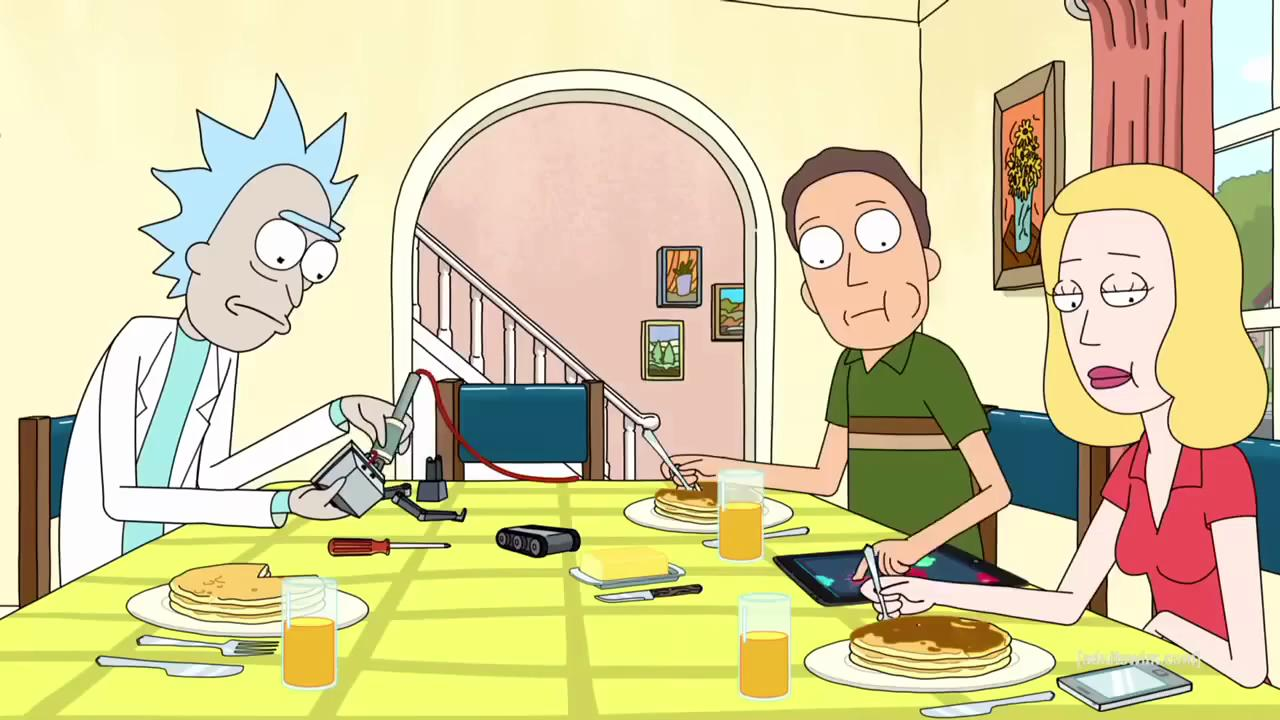

In [5]:
video_table.show()

Do you recognise this Rick & Morty episode?


### Step 1: Extracting the audio from the video


Added 1 column value with 0 errors in 0.78 s (1.28 rows/s)


video,audio
,

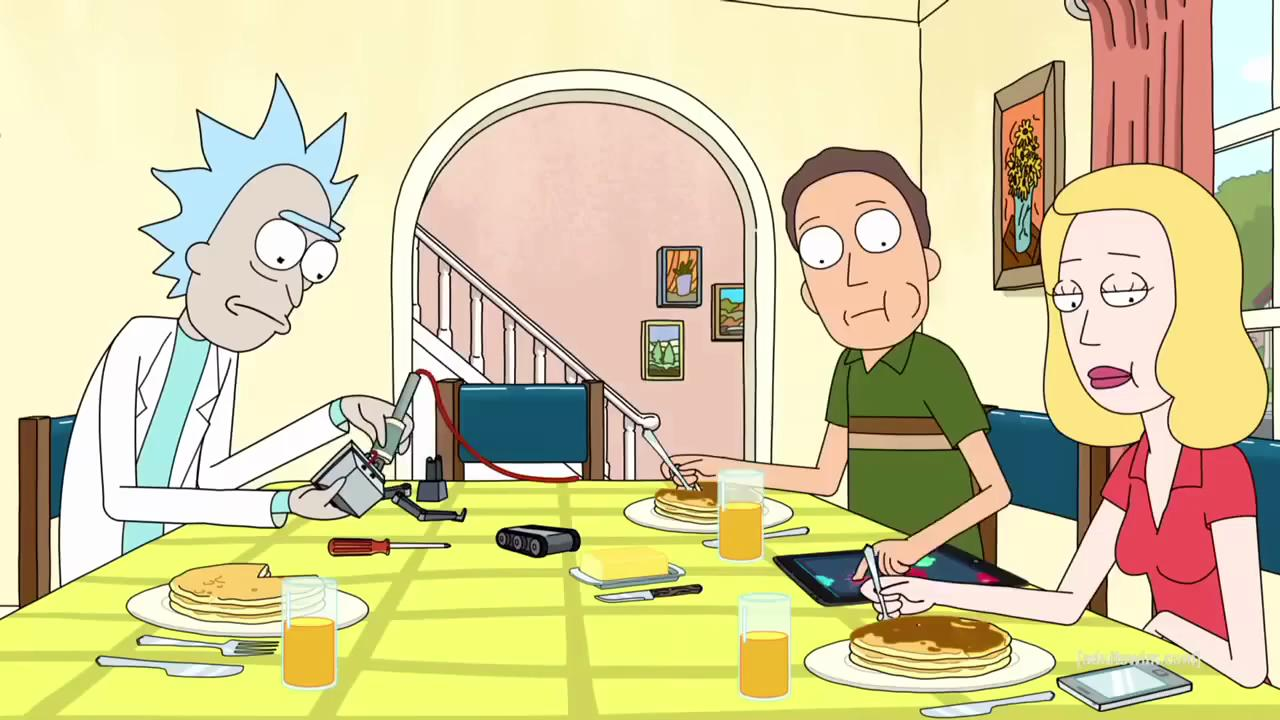

In [6]:
from pixeltable.functions.video import extract_audio

video_table.add_computed_column(
    audio=extract_audio(video_table.video, format="mp3"), if_exists="ignore"
)
video_table.show()

As you can see in the table above, we have two columns now. One column contains the video, and the other column contains the audio. Now, we need to split the audio into chunks.


### Step 2: Splitting the audio


In [7]:
from pixeltable.iterators.audio import AudioSplitter

audio_view = pxt.create_view(
    "test.audio_chunks",
    video_table,
    iterator=AudioSplitter.create(
        audio=video_table.audio,
        chunk_duration_sec=10.0,
        overlap_sec=1.0,
        min_chunk_duration_sec=1.0,
    ),
    if_exists="replace_force",
)

/var/folders/y5/krvnrzy131g_d3kf9g58cbgdrpb3fq/T/ipykernel_82738/2020168836.py:6: DeprecationWarning: Call to deprecated function (or staticmethod) create. (create() is deprecated; use `pixeltable.functions.audio.audio_splitter` instead) -- Deprecated since version 0.5.6.
  iterator=AudioSplitter.create(


pos,start_time_sec,end_time_sec,audio_chunk,video,audio
0,0.023,10.008,,,
1,9.024,19.008,,,

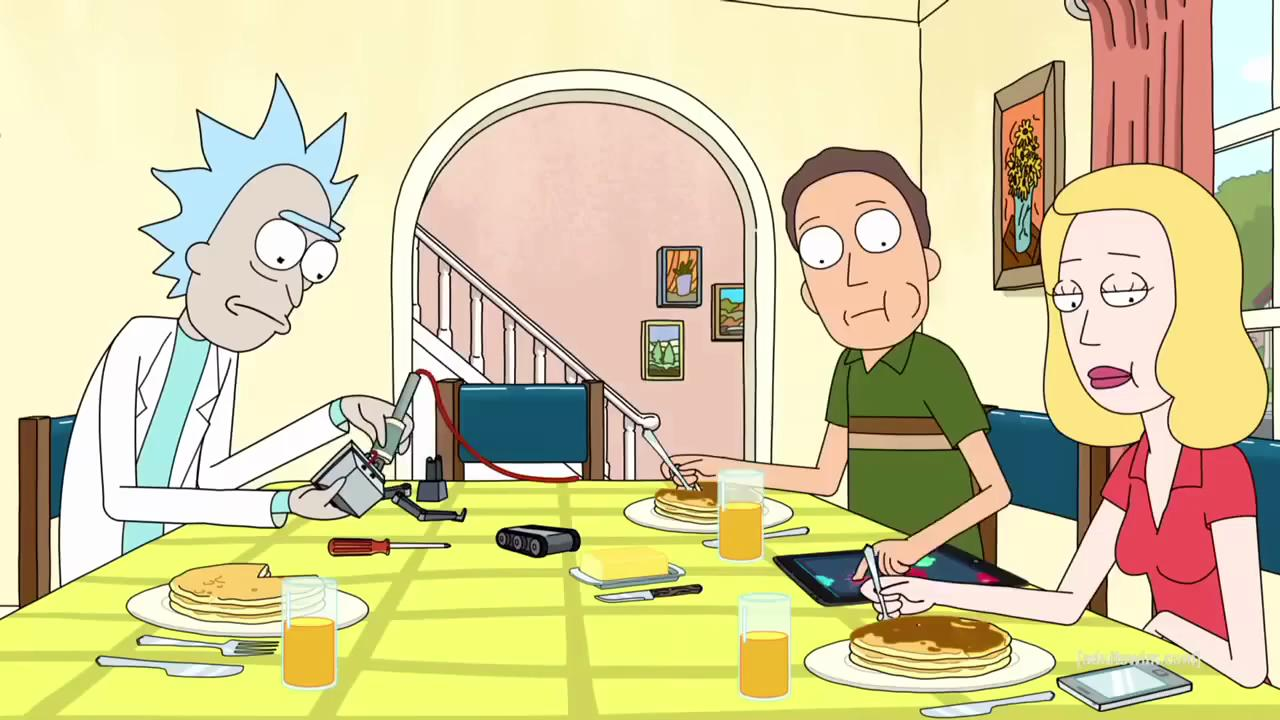
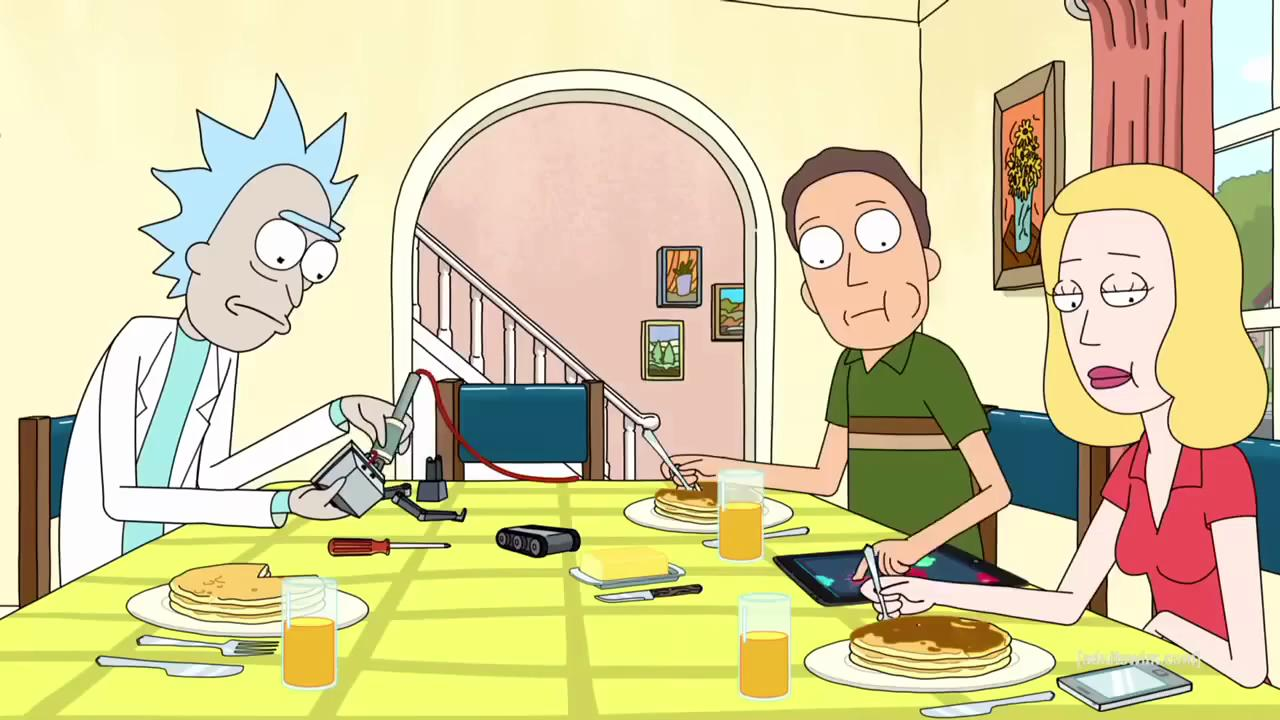

In [8]:
audio_view.show(2)

Notice that, apart from the `audio_chunk` column, we also have two additional columns, giving information about the start and end time in seconds.


### Step 3: Transcription with GPT-4o Mini


In [9]:
from pixeltable.functions import openai

audio_view.add_computed_column(
    transcription=openai.transcriptions(
        audio=audio_view.audio_chunk, model="gpt-4o-mini-transcribe"
    )
)

Added 7 column values with 0 errors in 4.97 s (1.41 rows/s)


7 rows updated.

pos,start_time_sec,end_time_sec,audio_chunk,transcription,video,audio
0,0.023,10.008,,"{""text"": ""Hey Rick, I have to make a project for the science fair this weekend. You think you could help me out? Whatever. Well, I mean, traditionally, science fairs are..."", ""usage"": {""type"": ""tokens"", ""input_tokens"": 100, ""total_tokens"": 139, ""output_tokens"": 39, ""input_token_details"": {""text_tokens"": 0, ""audio_tokens"": 100}}, ""logprobs"": null}",,
1,9.024,19.008,,"{""text"": ""Science fairs are a father-son thing. Well, scientifically, traditions are an idiot thing. Morty, I think it would be fun for you to work on a science project with your dad."", ""usage"": {""type"": ""tokens"", ""input_tokens"": 100, ""total_tokens"": 141, ""output_tokens"": 41, ""input_token_details"": {""text_tokens"": 0, ""audio_tokens"": 100}}, ""logprobs"": null}",,
2,18.024,28.008,,"{""text"": ""Yeah, Dad, why don't we do it together? Yes! You backed the right horse on this one, son."", ""usage"": {""type"": ""tokens"", ""input_tokens"": 100, ""total_tokens"": 126, ""output_tokens"": 26, ""input_token_details"": {""text_tokens"": 0, ""audio_tokens"": 100}}, ""logprobs"": null}",,
3,27.024,37.008,,"{""text"": ""Work on this one, son. We'll get out the crayons, brew some coffee, and knock this thing out in two or three days. What is my purpose? Pass the butter."", ""usage"": {""type"": ""tokens"", ""input_tokens"": 100, ""total_tokens"": 139, ""output_tokens"": 39, ""input_token_details"": {""text_tokens"": 0, ""audio_tokens"": 100}}, ""logprobs"": null}",,
4,36.024,46.008,,"{""text"": ""Thank you. Dad, I need a ride to work. Maybe Rick can give you a..."", ""usage"": {""type"": ""tokens"", ""input_tokens"": 100, ""total_tokens"": 121, ""output_tokens"": 21, ""input_token_details"": {""text_tokens"": 0, ""audio_tokens"": 100}}, ""logprobs"": null}",,
5,45.024,55.008,,"{""text"": ""Rick can give you a ride. I'm helping Morty with science. I'm busy. Doing what? Uh, anything else? What is my purpose?"", ""usage"": {""type"": ""tokens"", ""input_tokens"": 100, ""total_tokens"": 132, ""output_tokens"": 32, ""input_token_details"": {""text_tokens"": 0, ""audio_tokens"": 100}}, ""logprobs"": null}",,
6,54.024,60.888,,"{""text"": ""What is my purpose? You pass butter. Oh my God. Yeah, welcome to the club, pal."", ""usage"": {""type"": ""tokens"", ""input_tokens"": 68, ""total_tokens"": 92, ""output_tokens"": 24, ""input_token_details"": {""text_tokens"": 0, ""audio_tokens"": 68}}, ""logprobs"": null}",,

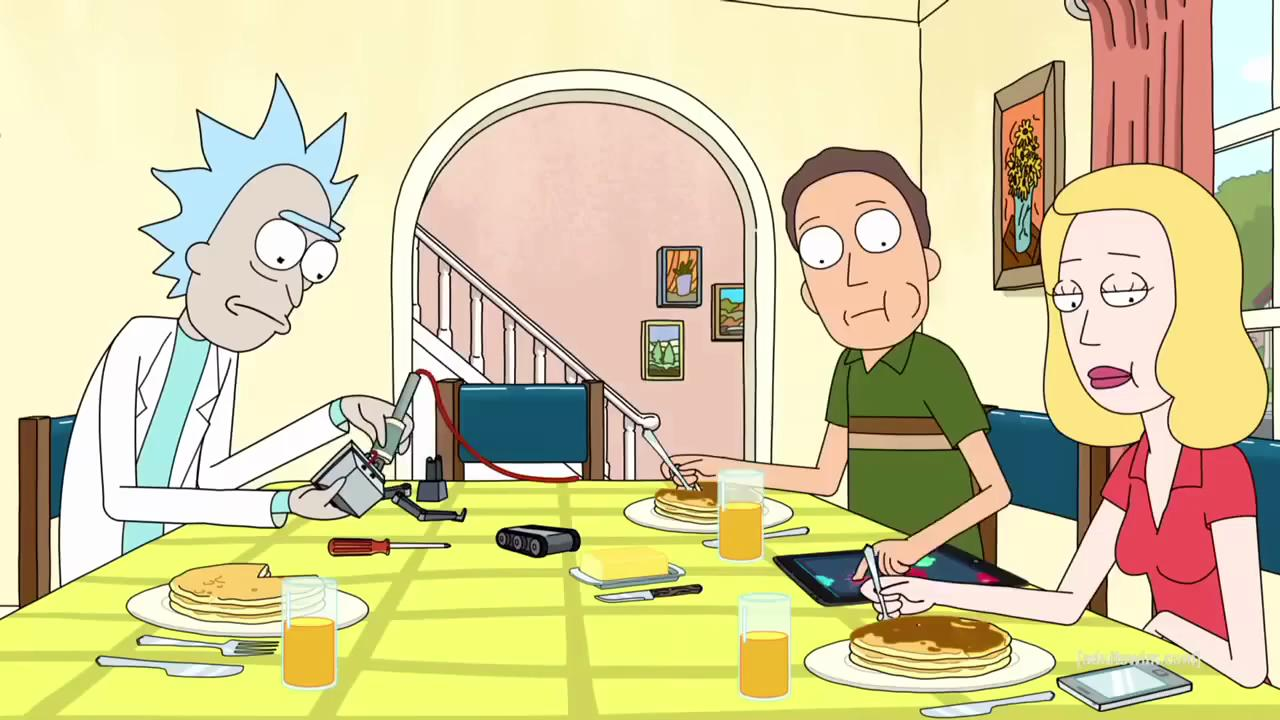
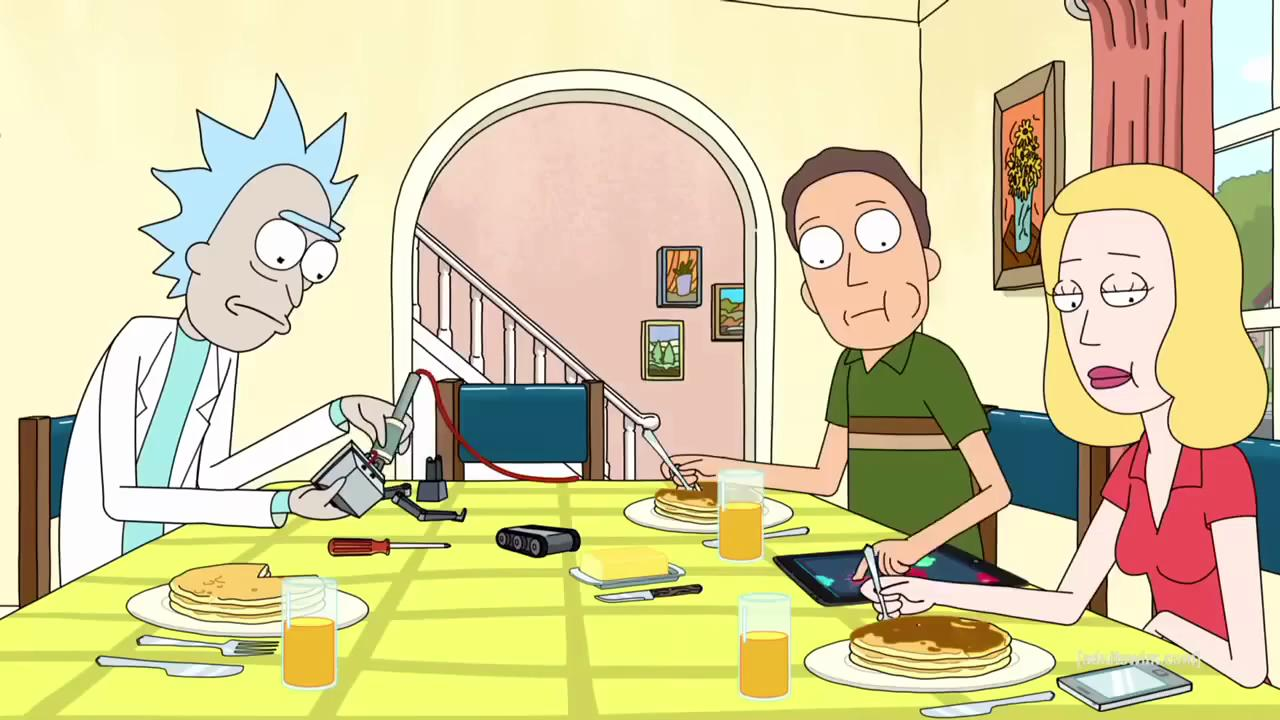
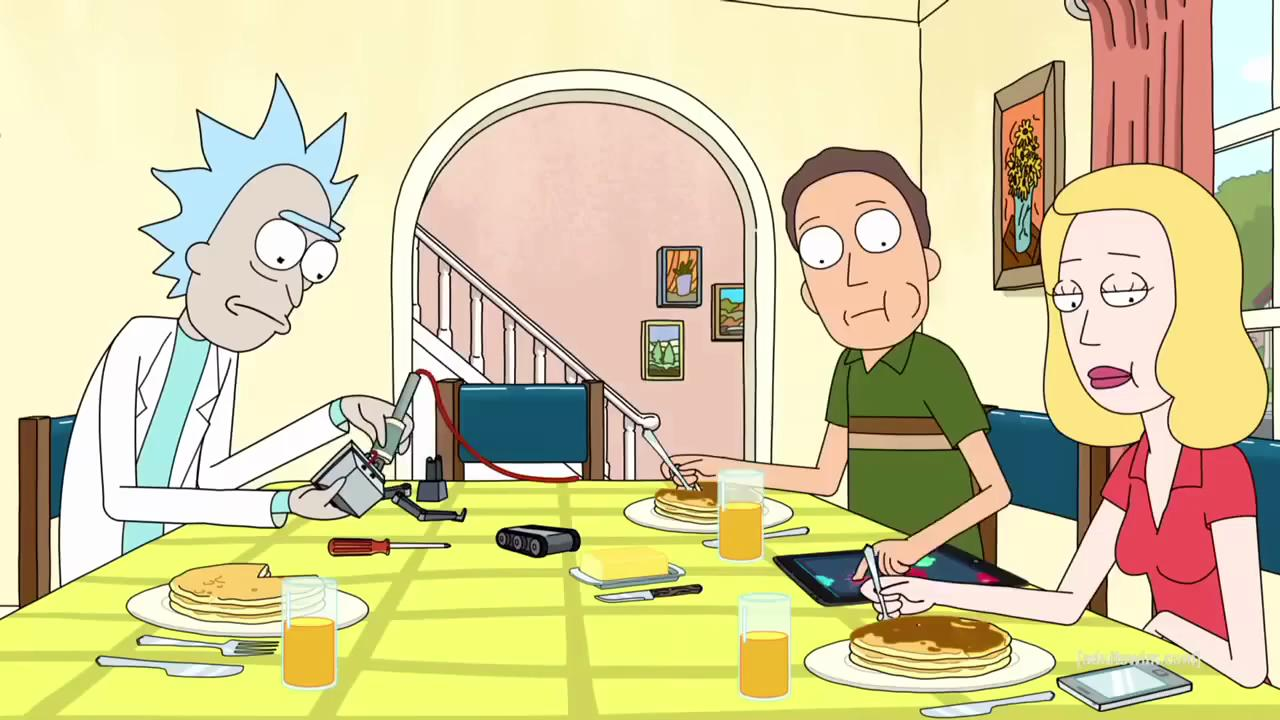
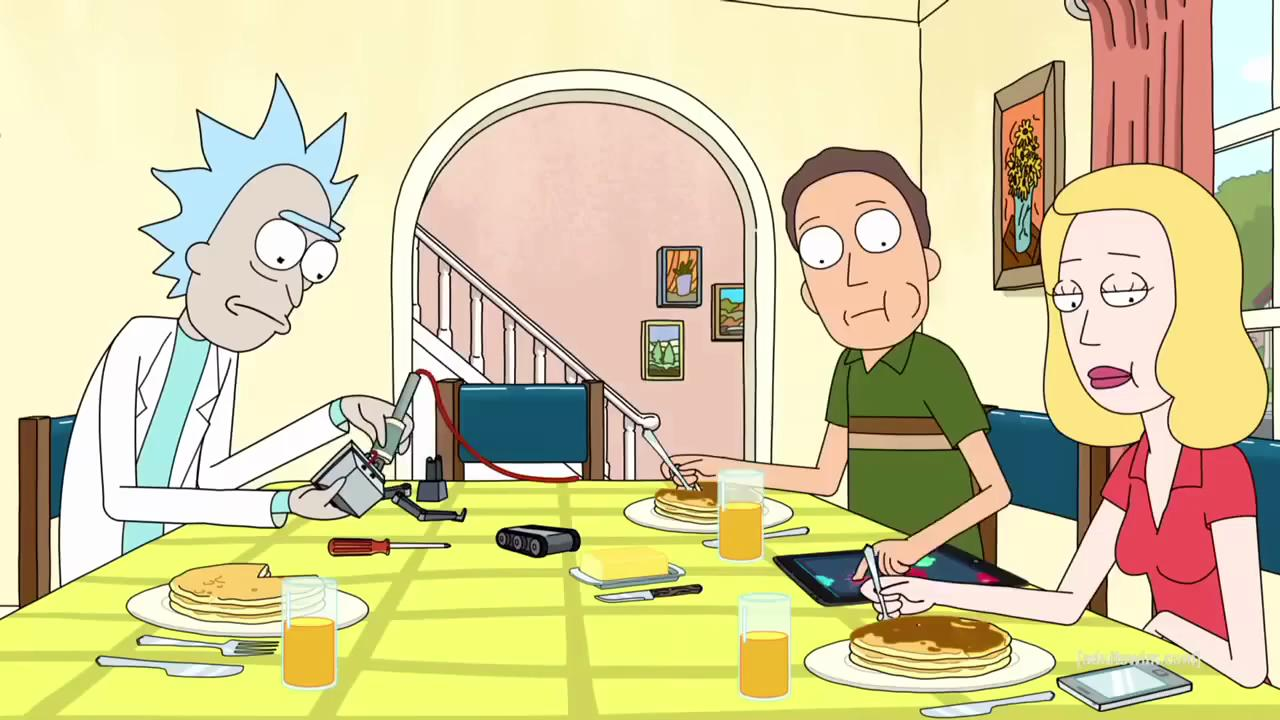
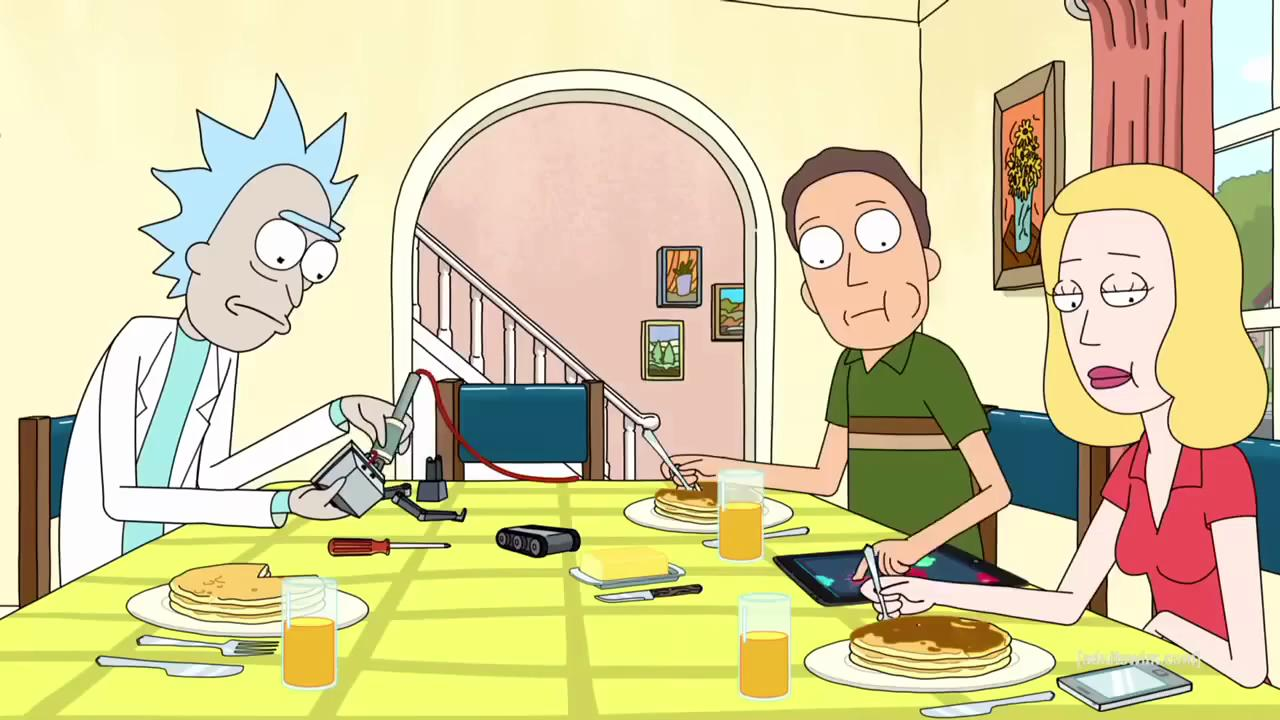
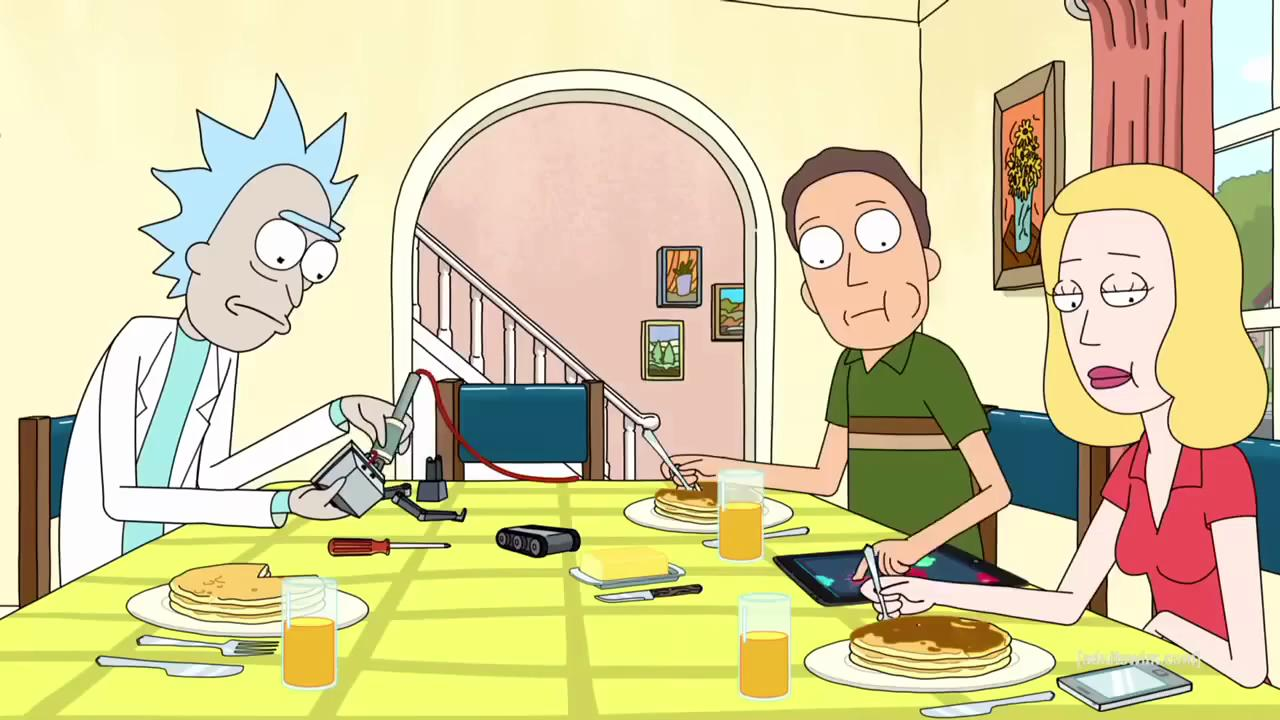
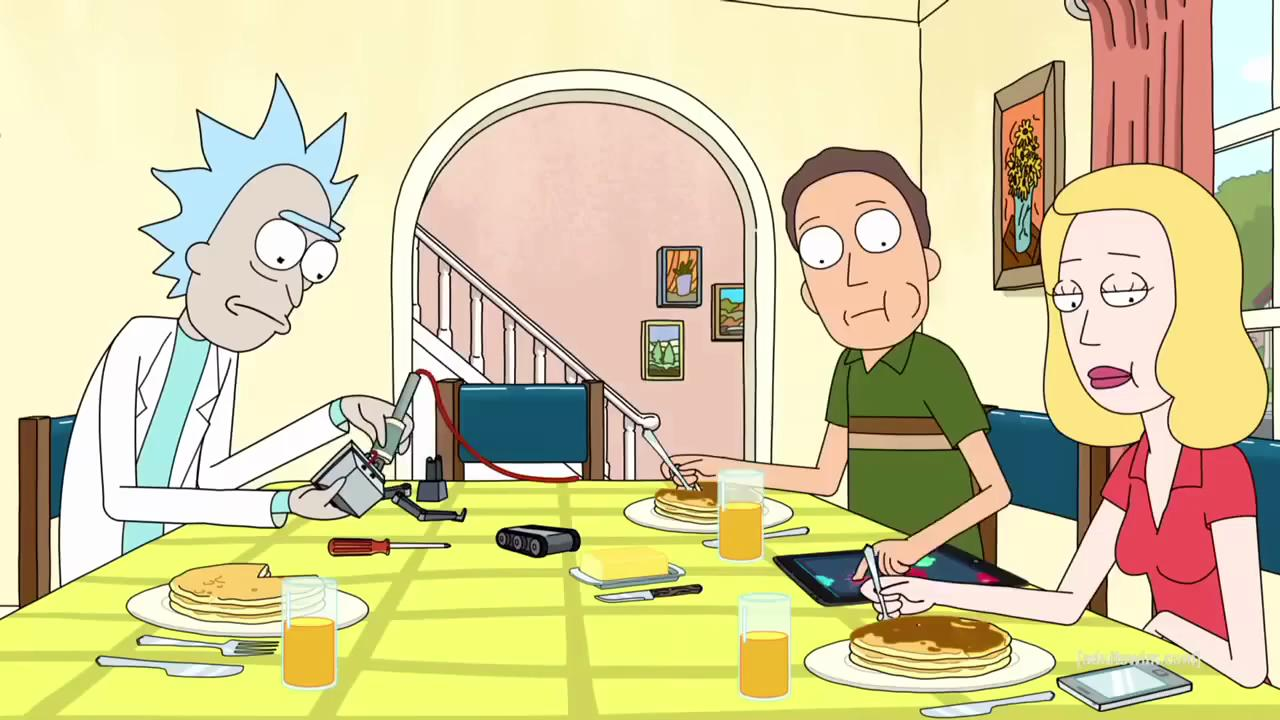

In [10]:
audio_view.order_by(audio_view.pos).show(10)

A new column has appeared, containing the transcription about the corresponding audio chunk! If you look at the content, you'll notice it has a lot of metadata information. We just need the `text` attribute.


### Step 4: Extracting the text from the transcription


In [ ]:
from kubrick_mcp.video.ingestion.functions import extract_text_from_chunk

audio_view.add_computed_column(
    chunk_text=extract_text_from_chunk(audio_view.transcription),
    if_exists="ignore",
)

In [ ]:
audio_view.order_by(audio_view.pos).show(1)

If you look at the `chunk_text` column, you'll see the text transcription (just the string).


### Step 5: Creating an embedding index for audio transcriptions


In [13]:
from pixeltable.functions.openai import embeddings

embed_model = embeddings.using(model="text-embedding-3-small")

audio_view.add_embedding_index(
    column=audio_view.chunk_text,
    string_embed=embed_model,
    if_exists="replace_force",
    idx_name="chunks_index",
)

You can check how this embedding index works by passing some query. The code below will take care of check the most similar audio_chunk to the user query.


In [14]:
audio_sims = audio_view.chunk_text.similarity("you pass the butter")

In [15]:
results = audio_view.select(
    audio_view.pos,
    audio_view.start_time_sec,
    audio_view.end_time_sec,
    similarity=audio_sims,
).order_by(audio_sims, asc=False)

In [22]:
top_k_entry = results.limit(1).collect()[0]

In [ ]:
top_k_entry

We can check the clip by using the `extract_video_clip` helper function.


In [ ]:
from kubrick_mcp.video.ingestion.tools import extract_video_clip

video_clip = extract_video_clip(
    video_path=video_path,
    start_time=top_k_entry["start_time_sec"],
    end_time=top_k_entry["end_time_sec"],
    output_path="./data/pass_the_butter_clip_sim_audio.mp4",
)

In [ ]:
from IPython.display import Video

Video(video_clip.filename)

### Step 6: Splitting the video in frames


In [ ]:
from pixeltable.iterators.video import FrameIterator

frames_view = pxt.create_view(
    "test.frames_view",
    video_table,
    iterator=FrameIterator.create(video=video_table.video, fps=0.5),
    if_exists="ignore",
)

In [ ]:
frames_view.show(3)

To access visual content, we need to sample the video, placing each frame in a row. After that, we just need to create an embedding index for the frames. We'll use CLIP embeddings for this one.


### Step 7: Creating frame embedding index


In [ ]:
from pixeltable.functions.huggingface import clip

frames_view.add_embedding_index(
    column=frames_view.frame,
    image_embed=clip.using(model_id="openai/clip-vit-base-patch32"),
)

As we did with the audio embedding index, we can also provide an image and check the clip more similar to it. For example, let's use the following picture.


In [9]:
from PIL import Image

img = Image.open("./data/sad_robot.png")

In [ ]:
img

In [11]:
image_sims = frames_view.frame.similarity(img)

In [12]:
results = frames_view.select(
    frames_view.pos_msec,
    frames_view.frame,
    similarity=image_sims,
).order_by(image_sims, asc=False)

In [13]:
top_k_entry = results.limit(1).collect()[0]

In [ ]:
top_k_entry

In [ ]:
top_k_entry["frame"]

In [ ]:
from kubrick_mcp.video.ingestion.tools import extract_video_clip


video_clip = extract_video_clip(
    video_path=video_path,
    start_time=top_k_entry["pos_msec"] / 1000.0 - 3,
    end_time=top_k_entry["pos_msec"] / 1000.0 + 3,
    output_path="./data/pass_the_butter_clip_sim_image.mp4",
)

In [ ]:
from IPython.display import Video

Video(video_clip.filename)

### Step 8: Add captions for each frame


In [ ]:
frames_view.show(1)

In [ ]:
from pixeltable.functions.openai import vision

frames_view.add_computed_column(
    im_caption=vision(
        prompt="Describe what is happening in the image",
        image=frames_view.frame,
        model="gpt-4o-mini",
    )
)

In [ ]:
frames_view.show(1)

### Step 9: Creating caption embedding index


In [33]:
embed_model = embeddings.using(model="text-embedding-3-small")

frames_view.add_embedding_index(column=frames_view.im_caption, string_embed=embed_model)

In [34]:
caption_sims = frames_view.im_caption.similarity(
    "Text message saying 'your father is insecure about his intelligence'"
)

In [ ]:
caption_sims

In [36]:
results = frames_view.select(
    frames_view.pos_msec,
    frames_view.im_caption,
    similarity=caption_sims,
).order_by(caption_sims, asc=False)

In [37]:
top_k_entry = results.limit(1).collect()[0]

In [ ]:
top_k_entry

In [ ]:
from kubrick_mcp.video.ingestion.tools import extract_video_clip

video_clip = extract_video_clip(
    video_path=video_path,
    start_time=top_k_entry["pos_msec"] / 1000.0 - 3,
    end_time=top_k_entry["pos_msec"] / 1000.0 + 3,
    output_path="./data/pass_the_butter_clip_sim_caption2.mp4",
)

In [ ]:
from IPython.display import Video

Video("./data/pass_the_butter_clip_sim_caption.mp4")

### Conclusion


These three embedding indexes will be used used by our MCP Server to fetch the most relevant content from the videos. But of course, the Agent won't be aware of the inner workings, since that's exactly the goal of the MCP Server!
